In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

In [41]:
neet = pd.read_csv("../data/NEET_result.csv", encoding='latin-1')


Key changes made specifically for all_data.csv:
- Added `engine='python'` for more flexible parsing than the C engine
- Implemented `chunksize=1000` to read the file in smaller pieces and avoid buffer overflow
- Added `quoting=3` to handle problematic quote characters
- Tried different encoding (`utf-8` vs `latin-1`)
- Added error handling to identify which method works for your specific file

In [42]:
print(neet.head())
print(neet.info())
print(neet.describe())

   dummy_srlno  marks                             state        city  \
0   1101010001     46  ANDAMAN AND NICOBAR ISLANDS (UT)  PORT BLAIR   
1   1101010002    226  ANDAMAN AND NICOBAR ISLANDS (UT)  PORT BLAIR   
2   1101010003    449  ANDAMAN AND NICOBAR ISLANDS (UT)  PORT BLAIR   
3   1101010004    424  ANDAMAN AND NICOBAR ISLANDS (UT)  PORT BLAIR   
4   1101010005    222  ANDAMAN AND NICOBAR ISLANDS (UT)  PORT BLAIR   

                center_name  center_number  
0  KENDRIYA VIDYALAYA NO. 1         110101  
1  KENDRIYA VIDYALAYA NO. 1         110101  
2  KENDRIYA VIDYALAYA NO. 1         110101  
3  KENDRIYA VIDYALAYA NO. 1         110101  
4  KENDRIYA VIDYALAYA NO. 1         110101  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2333120 entries, 0 to 2333119
Data columns (total 6 columns):
 #   Column         Dtype 
---  ------         ----- 
 0   dummy_srlno    int64 
 1   marks          int64 
 2   state          object
 3   city           object
 4   center_name    object
 5


Key changes made:
- Added `engine='python'` which is more flexible than the default C engine
- Implemented chunking with `chunksize=1000` to read files in smaller pieces
- Added different encoding options (`utf-8` vs `latin-1`)
- Added `quoting=3` to handle files with problematic quote characters
- Wrapped everything in try-except blocks to handle failures gracefully
- Added error messages to help identify which approach works

In [43]:
print(neet.isnull().sum())


dummy_srlno      0
marks            0
state            0
city             0
center_name      0
center_number    0
dtype: int64


In [44]:
print(neet.duplicated().sum())


0


In [ ]:
#marks distribution
plt.figure(figsize=(12,6))
sns.histplot(neet['marks'], bins=30, kde=True)
plt.title("NEET Marks Distribution")
plt.xlabel("Marks")
plt.ylabel("Number of Students")
plt.show()

In [ ]:
#top performing states
state_avg = neet.groupby('state')['marks'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
state_avg.plot(kind='bar')
plt.title("Top States by Average NEET Marks")
plt.ylabel("Average Marks")
plt.show()
#Certain states consistently show stronger academic performance

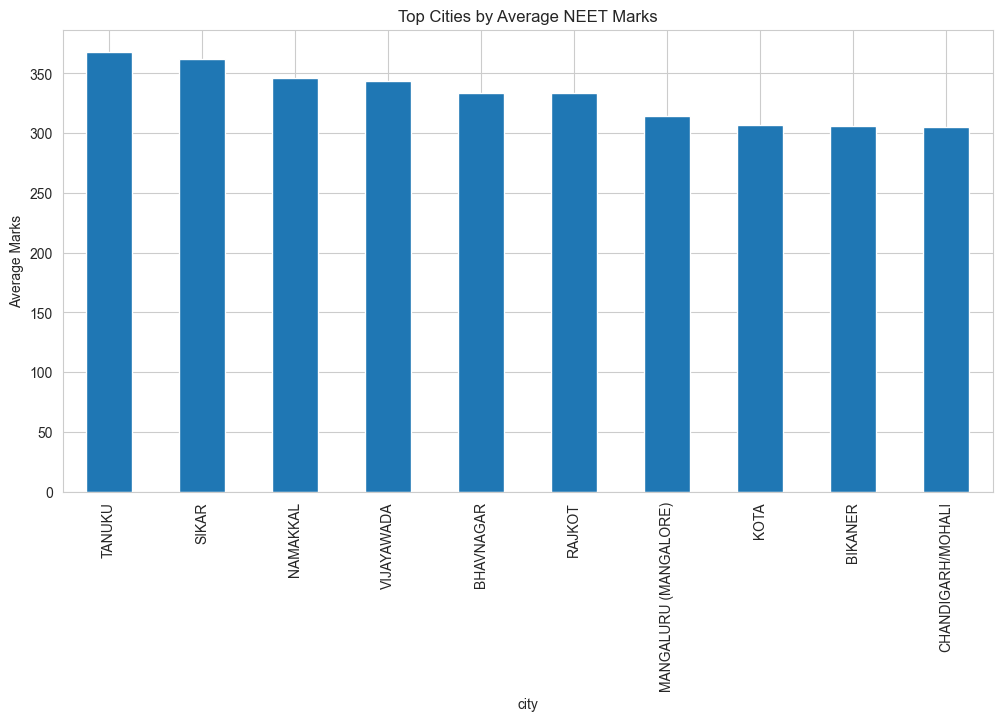

In [28]:
#city wise performance
city_avg = neet.groupby('city')['marks'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
city_avg.plot(kind='bar')
plt.title("Top Cities by Average NEET Marks")
plt.ylabel("Average Marks")
plt.show()

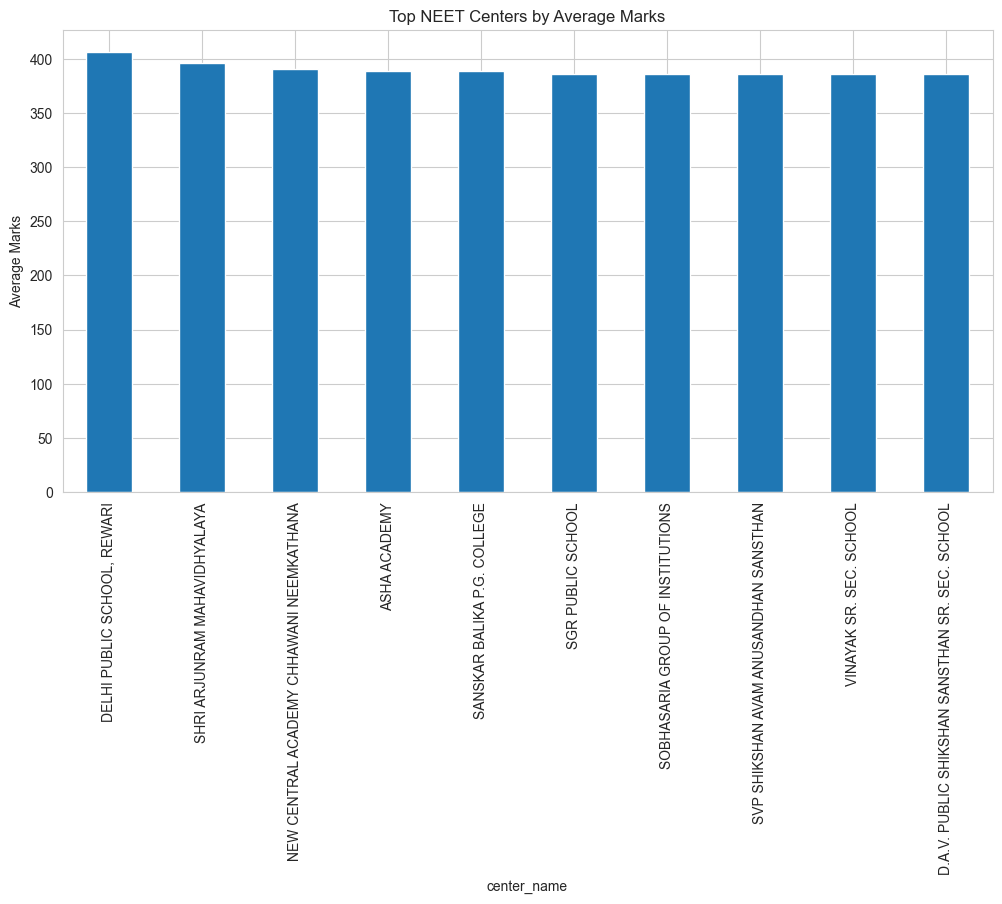

In [29]:
#highest performing center
center_avg = neet.groupby('center_name')['marks'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
center_avg.plot(kind='bar')
plt.title("Top NEET Centers by Average Marks")
plt.ylabel("Average Marks")
plt.show()

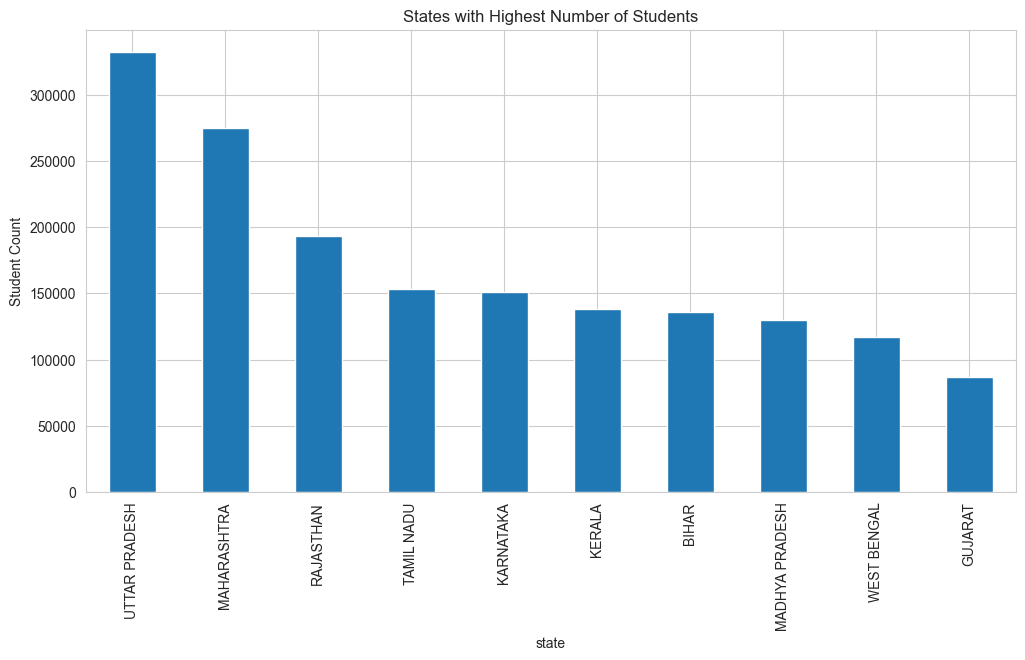

In [30]:
#state wise count
plt.figure(figsize=(12,6))
neet['state'].value_counts().head(10).plot(kind='bar')
plt.title("States with Highest Number of Students")
plt.ylabel("Student Count")
plt.show()

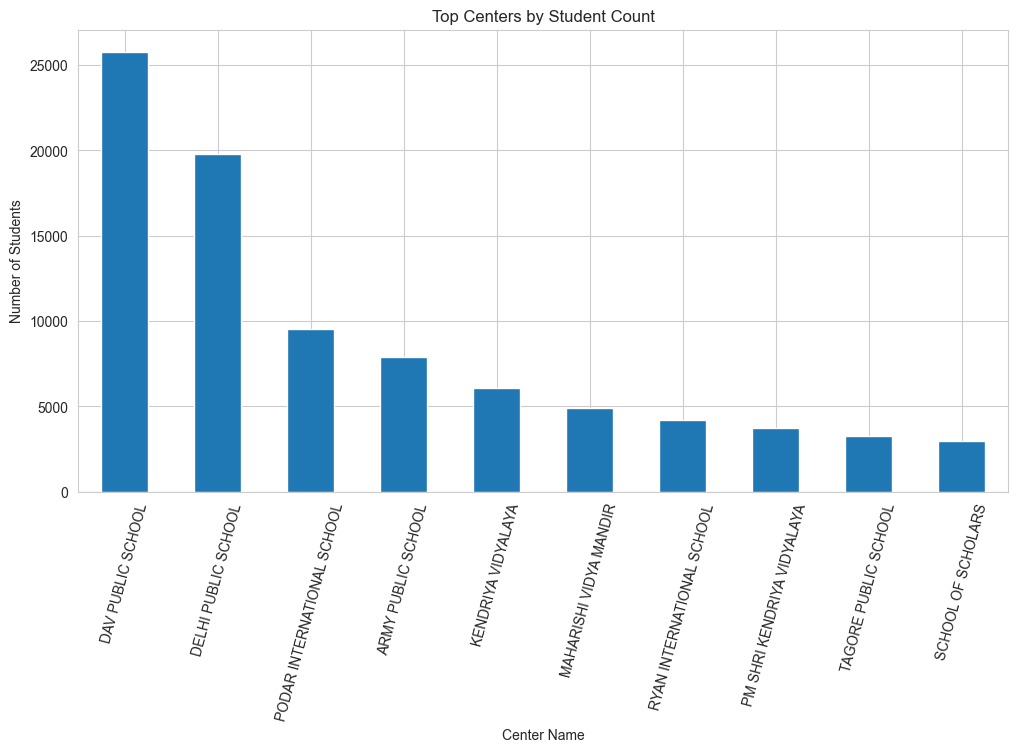

In [31]:
top_centers = neet['center_name'].value_counts().head(10)

plt.figure(figsize=(12,6))

top_centers.plot(kind='bar')

plt.title("Top Centers by Student Count")
plt.xlabel("Center Name")
plt.ylabel("Number of Students")

plt.xticks(rotation=75)

plt.show()

In [46]:
# High Score Concentration Analysis

high_score_centers = (
    neet.groupby('center_name')['marks']
    .mean()
    .sort_values(ascending=False)
)

print("\nTop 20 High Score Centers")
print(high_score_centers.head(20))



Top 20 High Score Centers
center_name
DELHI PUBLIC SCHOOL, REWARI                        406.340909
SHRI ARJUNRAM MAHAVIDHYALAYA                       396.413366
NEW CENTRAL ACADEMY CHHAWANI NEEMKATHANA           390.276353
ASHA ACADEMY                                       388.800000
SANSKAR BALIKA P.G. COLLEGE                        388.498834
SGR PUBLIC SCHOOL                                  386.225951
SOBHASARIA GROUP OF INSTITUTIONS                   386.187251
SVP SHIKSHAN AVAM ANUSANDHAN SANSTHAN              386.016771
VINAYAK SR. SEC. SCHOOL                            386.006303
D.A.V. PUBLIC SHIKSHAN SANSTHAN SR. SEC. SCHOOL    385.842629
DANTA MAHAVIDHALAYA                                385.331765
PINK PEARL SHIKSHAN SANSTHAN SR. SEC. SCHOOL       385.077689
SHRI BHAGWANDAS TODI COLLEGE                       384.797320
SEM SCHOOL NEEMKATHANA                             384.647679
THE SPECTRUM ACADEMY                               384.630088
GOENKA PUBLIC SCHOOL           

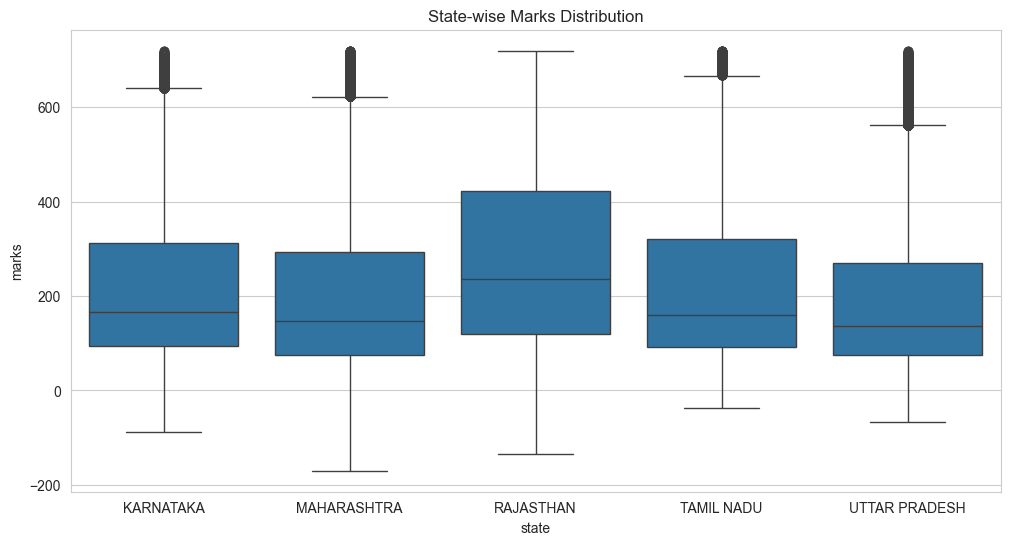

In [48]:
#State-wise Marks Spread

top_states = neet['state'].value_counts().head(5).index

filtered = neet[neet['state'].isin(top_states)]

plt.figure(figsize=(12,6))

sns.boxplot(x='state', y='marks', data=filtered)

plt.title("State-wise Marks Distribution")

plt.show()



In [49]:
#to 20 highest score 2024
top_students = (
    neet.sort_values(by='marks', ascending=False)
    .head(20)
)

print("\nTop 20 Highest Scores")

print(
    top_students[
        ['marks', 'state', 'city', 'center_name']
    ]
)



Top 20 Highest Scores
         marks           state                        city  \
1442285    720       RAJASTHAN                      JAIPUR   
19977      720  ANDHRA PRADESH                  VIJAYAWADA   
632215     720       KARNATAKA            BENGALURU- URBAN   
2260373    720     WEST BENGAL                     KOLKATA   
1619115    720       RAJASTHAN                       SIKAR   
1473150    720       RAJASTHAN                        KOTA   
1418058    720          PUNJAB     PATIALA/FATEHGARH SAHIB   
1275135    720     MAHARASHTRA                      MUMBAI   
1670499    720      TAMIL NADU                     CHENNAI   
427497     720         GUJARAT                       SURAT   
1250850    720     MAHARASHTRA                      NAGPUR   
2153287    720   UTTAR PRADESH                     LUCKNOW   
604123     720       JHARKHAND                      RANCHI   
1492528    720       RAJASTHAN                     UDAIPUR   
1122906    720     MAHARASHTRA                 

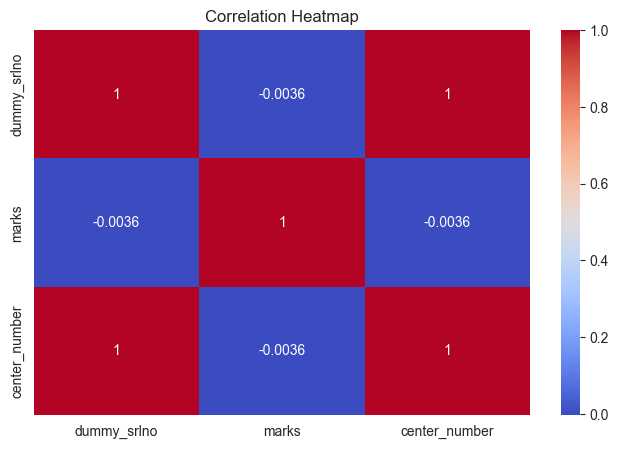

In [50]:
#Heatmap Insight
#The correlation heatmap showed very weak relationships between numeric identifier columns and student marks. 
#This indicates that variables such as center number orserial number do not directly influence student performance and mainly act as
#identification fields rather than academic indicators.
numeric_cols = neet.select_dtypes(include=np.number)

plt.figure(figsize=(8,5))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [52]:
plt.savefig("../visuals/marks_distribution.png")

plt.savefig("../visuals/state_analysis.png")

plt.savefig("../visuals/lowest_state_analysis.png")

plt.savefig("../visuals/city_analysis.png")

plt.savefig("../visuals/student_participation.png")

plt.savefig("../visuals/center_analysis.png")

plt.savefig("../visuals/top_centers.png")

plt.savefig("../visuals/boxplot.png")

plt.savefig("../visuals/statewise_boxplot.png")

plt.savefig("../visuals/heatmap.png")

<Figure size 1000x600 with 0 Axes>